In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Imports Libraries and Tools

In [15]:

import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data
from sklearn.model_selection import train_test_split

##Load Datasets

In [16]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/MRIImages/Training'
test_dir = '/content/drive/MyDrive/MRIImages/Testing'

# Load and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


##Data Visualization

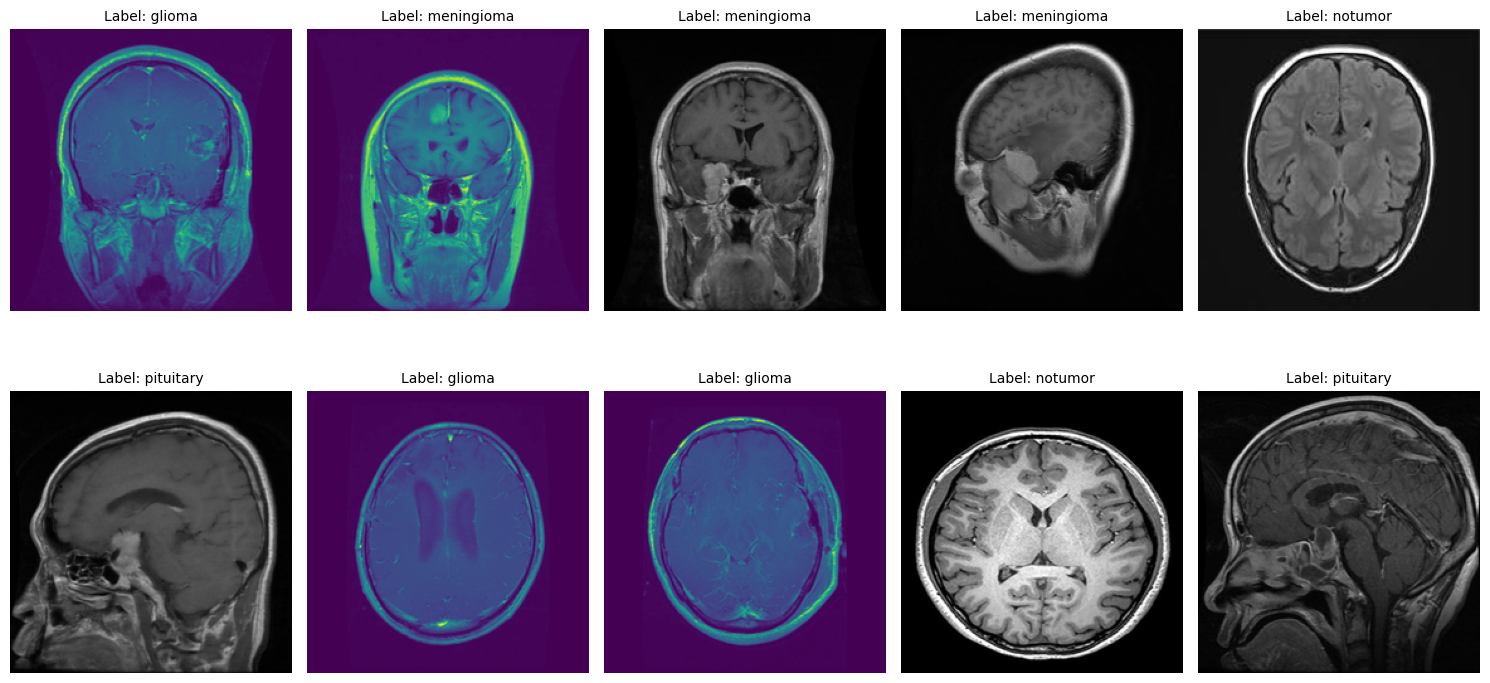

In [17]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  # Load image
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((224, 224)) # Resize to consistent size

  # Display image
  axes[i].imshow(img)
  axes[i].axis('off') # Hide axis
  # Display class label in the second row
  axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

##Image Preprocessing (Helper Functions)

In [18]:
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)

# Create fixed label mapping
class_names = sorted(os.listdir(train_dir))
label_to_index = {label: i for i, label in enumerate(class_names)}

def preprocess_image(image):
  image = np.array(image) / 255.0
  return image

#Image Augmentation function
def augment_image(image):
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2)) # Random brightness
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2)) # Random contrast
  image = np.array(image) / 255.0 # Normalize pixel values to [0, 1]
  return image

# Load images and apply augmentation
def open_images(paths, augment=False):
  images = []
  for path in paths:
    image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    if augment:
      image = augment_image(image)
    else:
      image = preprocess_image(image)
    images.append(image)
  return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
  unique_labels = os.listdir(train_dir) # Ensure unique labels are determined
  encoded = [unique_labels.index(label) for label in labels]
  return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=20, augment=False):
  while True:
    paths, labels = shuffle(paths, labels)
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i + batch_size]
      batch_labels = labels[i:i + batch_size]

      batch_images = open_images(batch_paths, augment=augment)
      batch_labels = encode_label(batch_labels)

      yield batch_images, batch_labels

## Clean custom CNN

In [ ]:
def build_core_cnn(input_shape, num_classes):
  model = Sequential()

  # Block 1
  model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))

  # Block 2
  model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))

  # Block 3
  model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))

  # Classifier
  model.add(Flatten())
  model.add(Dense(128, activation='relu'))
  model.add(Dropout(0.4)) # reduce the overfitting problem
  model.add(Dense(num_classes, activation='softmax'))

  return model


## Compile the Model

In [20]:
cnn_model = build_core_cnn(input_shape=(128,128,3), num_classes=4)

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train the cnn model

In [21]:
cnn_history = cnn_model.fit(
    datagen(train_paths, train_labels, batch_size=20, augment=True),
    steps_per_epoch=len(train_paths)//20,
    epochs=20,
    validation_data=datagen(val_paths, val_labels, batch_size=20, augment=False),
    validation_steps=len(val_paths) // 20
)

Epoch 1/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1311s 6s/step - accuracy: 0.7103 - loss: 0.8541 - val_accuracy: 0.3375 - val_loss: 2.6961
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.8051 - loss: 0.4760 - val_accuracy: 0.8125 - val_loss: 0.4333
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - accuracy: 0.8458 - loss: 0.3932 - val_accuracy: 0.8821 - val_loss: 0.3152
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - accuracy: 0.8815 - loss: 0.2887 - val_accuracy: 0.8920 - val_loss: 0.2843
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 29s 130ms/step - accuracy: 0.9103 - loss: 0.2373 - val_accuracy: 0.9027 - val_loss: 0.2954
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 29s 130ms/step - accuracy: 0.9297 - loss: 0.1771 - val_accuracy: 0.9187 - val_loss: 0.2111
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - accuracy: 0.9473 - loss: 0.1361 - val_accuracy: 0.9321 - val_loss: 0.1863
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 115ms/step - accuracy: 0.9567 - loss: 0.

## Evaluate the cnn model

In [ ]:
test_loss, test_acc = cnn_model.evaluate(
    datagen(test_paths, test_labels, batch_size=20),
    steps=len(test_paths) // 20
)
print("Test Accuracy:", test_acc)

## Transfer Learning CNN

In [ ]:
# Redeclaring augment_image to fix the ValueError
def augment_image(image): # 'image' is a PIL.Image.Image object here
  # Apply enhancements directly to the PIL Image
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  # Convert to numpy array AFTER enhancements
  image = np.array(image)
  # Normalize pixel values to [0, 1]
  image = image / 255.0
  return image

# Model architecture
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freez all layers of the VGG16 base model
for layer in base_model.layers:
  layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))) # Input layer
model.add(base_model) # Add VGG16 base model
model.add(Flatten()) # Flatten the output of the base model
model.add(Dropout(0.3)) # Dropout layer for regularization
model.add(Dense(128, activation='relu')) # Dense layer with ReLU activation
model.add(Dropout(0.2)) # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax')) # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size) # Steps per epoch
epochs = 5

# Train the model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 2861s 10s/step - loss: 0.4656 - sparse_categorical_accuracy: 0.8221
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 31s 112ms/step - loss: 0.2289 - sparse_categorical_accuracy: 0.9148
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step - loss: 0.1582 - sparse_categorical_accuracy: 0.9441
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 118ms/step - loss: 0.1258 - sparse_categorical_accuracy: 0.9539
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - loss: 0.0904 - sparse_categorical_accuracy: 0.9689


##Train and Val Plots

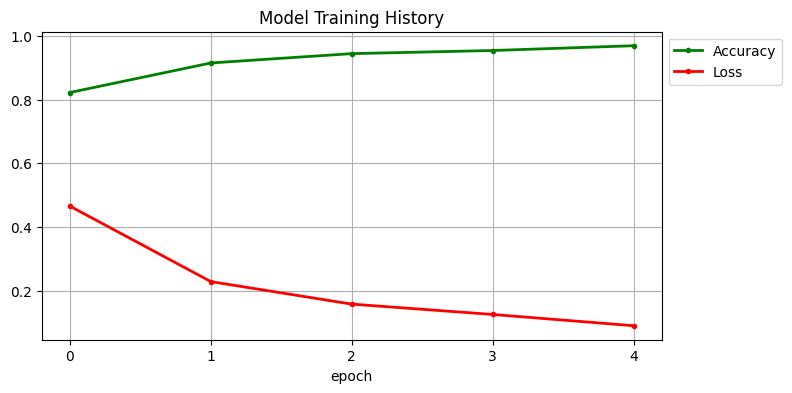

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()